# Data Preprocessing and Augmentation

Before training the CNN model the CIFAR-10 dataset was preprocessed to make it more suitable for image classification. The first step involved scaling the pixel values from the original range of 0 to 255 to a normalized range between 0 and 1. This was done to improve training stability and allow the neural network to learn more effectively.

The class labels were then converted into one-hot encoded vectors. Since CIFAR-10 is a multi-class classification problem with ten possible categories one-hot encoding allows each class label to be represented in a format suitable for the output layer of the CNN.

Data augmentation was considered as a possible improvement to the training process. It was not included in the final implementation because the final selected model focused on batch normalization, dropout and early stopping.

A separate validation split was also created from the training data so that model performance could be monitored during training while keeping the test data for final evaluation.

This preprocessing pipeline was chosen based on standard deep learning practice for image classification tasks and is appropriate for the CIFAR-10 dataset.


In [66]:
# Import required libraries
# TensorFlow is used to build and train the neural network
import tensorflow as tf

# Keras built-in dataset CIFAR-10
from tensorflow.keras.datasets import cifar10

# Used to convert class labels into one-hot encoded vectors
from tensorflow.keras.utils import to_categorical

# Used to split the training data into training and validation sets
from sklearn.model_selection import train_test_split

# Load the CIFAR-10 dataset
# The dataset contains 60,000 images size 32x32 pixels
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Normalize image pixel values
# Images originally contain pixel values from 0 to 255
# Neural networks perform better when input values are scaled
# Dividing by 255 converts pixel values into the range 0–1
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Split the original training data into training and validation sets
# This allows the model to be monitored during training without using the test set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

# Convert labels to one-hot encoding
# CIFAR-10 has 10 object classes
# One-hot encoding converts class numbers into binary vectors
# Example: class "3" becomes [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Display dataset shapes to verify everything loaded correctly
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation images shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images shape: (45000, 32, 32, 3)
Training labels shape: (45000, 10)
Validation images shape: (5000, 32, 32, 3)
Validation labels shape: (5000, 10)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


# Visualizing Sample Images

Before training the CNN model visualise some examples from the CIFAR-10 dataset. This helps confirm that the images were loaded correctly and shows the types of objects the model will need to classify.

The CIFAR-10 dataset contains 10 different classes including airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships and trucks. Displaying a small sample of images helps inspect the dataset and verify that the preprocessing steps have been applied correctly.


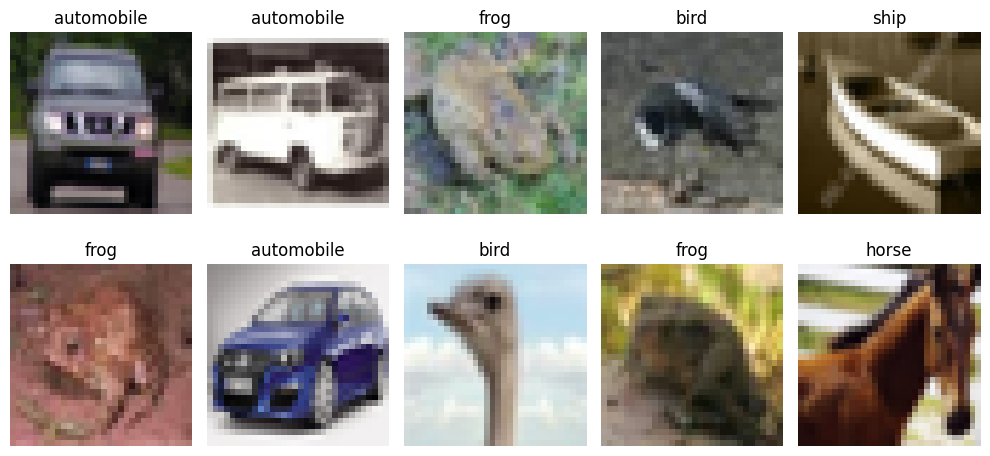

In [67]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import numpy as np

# Define the class names for CIFAR-10
# These correspond to the numeric labels in the dataset
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display the first 10 images from the training dataset
# This allows inspection of the dataset and confirmation that the images have loaded correctly
plt.figure(figsize=(10,5))
for i in range(10):

    # Create subplot grid
    plt.subplot(2,5,i+1)

    # Display image
    plt.imshow(X_train[i])

    # Show the class label for the image
    plt.title(class_names[np.argmax(y_train[i])])

    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Display images
plt.show()


# Model Architecture

Convolutional Neural Network (CNN) was chosen to classify the CIFAR-10 images. A CNN is more suitable than a standard neural network for image classification because it can automatically learn important visual features such as edges, patterns and shapes directly from the input images.

The model architecture used is made of multiple convolutional and pooling layers followed by fully connected layers. The convolutional layers are used to extract visual features from the images while the pooling layers reduce the spatial dimensions of the feature maps and help lower computational complexity. After feature extraction the output is flattened and passed through dense layers for classification.

The architecture includes:

- An input layer for 32 × 32 colour images
- Three convolutional layers with ReLU activation
- Max-pooling layers to reduce feature map size
- A flatten layer to convert feature maps into a one-dimensional vector
- A dense hidden layer with dropout for regularization
- An output layer with 10 neurons and softmax activation for multi-class classification

This architecture was selected because it is simple, effective and appropriate for the CIFAR-10 dataset. It has good balance between model complexity and performance and reduces overfitting using dropout.


In [68]:
# Build the CNN model
# A Sequential model is used because the layers are stacked one after another in order
from tensorflow.keras import layers, models

model = models.Sequential()

# Input layer and first convolution block
# The input shape matches CIFAR-10 image dimensions: 32x32x3
# Conv2D applies 32 filters of size 3x3 to learn low-level features such as edges
# MaxPooling reduces the spatial size of the feature maps.
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolution block
# This layer increases the number of filters to 64 so the model can learn more complex features
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolution block
# This layer uses 128 filters to capture higher-level image features.
model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the feature maps
# The Flatten layer converts the 2D feature maps into a 1D vector so that the data can be passed into dense layers
model.add(layers.Flatten())

# Fully connected layer
# A dense layer with 128 neurons is used to learn from the extracted features.
# ReLU is used as the activation function.
# Dropout is added to reduce overfitting by randomly disabling some neurons during training
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.5))

# Output layer
# The output layer has 10 neurons because CIFAR-10 has 10 classes.
# Softmax converts the outputs into probabilities for each class.
model.add(layers.Dense(10, activation="softmax"))

# Compile the model
# Adam is used as the optimizer because it performs well in practice.
# Categorical crossentropy is used because this is a multi-class problem.
# Accuracy is used as the main evaluation metric.
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display the model architecture summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Training and Evaluation

After defining the CNN architecture the model was trained using the CIFAR-10 training dataset. The goal of training is to allow the neural network to learn meaningful features from the images and correctly classify them into one of the ten categories.

The model was trained using the Adam optimizer which is common in deep learning due to its efficiency and adaptive learning rate. The categorical cross-entropy loss function was used because the task is a multi-class classification problem with ten possible output classes.

Accuracy: Measures the percentage of correctly classified images.  
Loss: Measures how well the model's predictions match the true labels.

During training the validation dataset was used to monitor performance after each epoch while the test set was kept for final evaluation.


In [ ]:
# Train the CNN model
# The model is trained using the training dataset.
# The validation dataset is used to monitor performance during training.
history = model.fit(

    # Training data
    X_train, y_train,

    # Number of samples processed before updating weights
    batch_size=64,

    # Number of times the model sees the entire dataset
    epochs=10,

    # Validation data used to evaluate performance after each epoch
    validation_data=(X_val, y_val)
)


Epoch 1/10


In [ ]:
# Visualize training performance
# These graphs show how the model performed during training.

# Plot training and validation accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Model Performance Analysis

The graph shows the training accuracy and validation accuracy of the CNN model over 10 epochs. The model starts with a relatively low training accuracy (around 40%) at the start while the validation accuracy is higher (approximately 55%). Training and validation accuracy steadily increase indicating that the model is successfully learning useful features from the dataset.

The training accuracy reaches approximately 78% while the validation accuracy reaches around 75%. This shows that the model performs well on both the training data and unseen validation data.

The gap between training accuracy and validation accuracy is small throughout training. This suggests that the model is not significantly overfitting and is able to generalize well to new data.

In conclusion the model has good learning behaviour and has a balance between training performance and generalization. Further improvements could be made by tuning hyperparameters or modifying the model architecture.


In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Loss Analysis

The graph shows the training loss and validation loss of the CNN model over 10 epochs.

The loss for both training and validation data steadily decreases showing that the model is improving and making more accurate predictions.

The training loss decreases consistently from approximately 1.6 to around 0.6 which shows that the model is learning effectively from the training data. The validation loss also decreases from around 1.25 to approximately 0.73 showing improved performance on unseen data.

The gap between training loss and validation loss is relatively small which shows that the model is generalizing well and not overfitting significantly.

The decreasing loss values for both training and validation data confirm that the model is learning effectively and improving its predictive performance over time.


# Model Improvement and Optimization

One improvement is hyperparameter tuning. Adjusting parameters such as the learning rate, batch size and number of epochs could lead to better model performance. Training the model for more epochs or using a smaller learning rate may allow the model to learn more detailed patterns.

Another improvement would be to increase the depth of the network by adding more convolutional layers. A deeper model can capture more complex features from the images which may improve classification accuracy.

Regularization techniques such as batch normalization or increasing dropout could also be applied to further reduce overfitting and improve generalization.

More advanced data augmentation techniques could be used to increase dataset diversity such as zooming or brightness adjustments.

Transfer learning could be applied by using pre-trained models such as VGG16 or ResNet. These models are trained on large datasets and can significantly improve performance when fine-tuned for CIFAR-10.


In [ ]:
# Build an improved CNN model
# This version adds Batch Normalization to improve training stability and help the model generalize better
improved_model = models.Sequential()

# Input layer
improved_model.add(layers.Input(shape=(32, 32, 3)))

# First convolution block
improved_model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Second convolution block
improved_model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Third convolution block
improved_model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu")))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Flatten feature maps into a 1D vector
improved_model.add(layers.Flatten())

# Fully connected layer
improved_model.add(layers.Dense(128, activation="relu"))

# Dropout helps reduce overfitting
improved_model.add(layers.Dropout(0.5))

# Output layer for 10 CIFAR-10 classes
improved_model.add(layers.Dense(10, activation="softmax"))

# Compile the improved model
improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
improved_model.summary()


In [ ]:
# Train the improved model with Early Stopping
# Early stopping helps prevent overfitting by stopping training when monitored performance stops improving
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss", # watch validation loss
    patience=3, # stop after 3 epochs with no improvement
    restore_best_weights=True # restore the best model weights
)

history_improved = improved_model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# Evaluate the improved model on the test set
improved_loss, improved_acc = improved_model.evaluate(X_test, y_test)
print("Improved Model Test Loss:", improved_loss)
print("Improved Model Test Accuracy:", improved_acc)


In [ ]:
# Plot training and validation accuracy for the improved model
plt.figure(figsize=(10, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss for the improved model
plt.figure(figsize=(10, 5))
plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Compare the original and improved model test accuracy
baseline_loss_check, baseline_acc_check = model.evaluate(X_test, y_test, verbose=0)
print("Original Model Test Accuracy:", baseline_acc_check)
print("Improved Model Test Accuracy:", improved_acc)


# Model Comparison

The baseline CNN model achieved a test accuracy while the improved CNN model achieved a higher test accuracy.

This demonstrates that techniques such as batch normalization and early stopping can enhance model performance.

The results are consistent with typical CNN performance on the CIFAR-10 dataset where simple architectures generally achieve accuracy between 70% and 80%.


In [ ]:
# Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict classes
y_pred = improved_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes))


# Confusion Matrix Analysis

The confusion matrix shows classification performance of the CNN model across all ten CIFAR-10 classes.

The model performs well with a high number of correct predictions along the diagonal of the matrix. This shows that the model is able to correctly classify most images.

Certain classes like automobiles, ships and trucks, show particularly strong performance with a high number of correct classifications. This suggests that these classes are easier for the model to distinguish with more distinct visual features.

Some classes show higher levels of misclassification. Cats and dogs are frequently confused with each other which is expected because they share similar visual characteristics. There is some confusion between trucks and automobiles as well as between deer and horses.

These misclassifications highlight the limitations of the model and suggest that it struggles more with visually similar categories. This is a common challenge in image classification tasks.


# Hyperparameter Tuning and Model Optimization

The baseline CNN achieved reasonable performance, but the confusion matrix showed that some visually similar classes were still difficult to distinguish. To improve performance, a small hyperparameter tuning study was carried out.

The hyperparameters selected for tuning were:

- learning rate
- batch size
- dropout rate

These were chosen because they have a strong influence on training stability, generalization, and overfitting. Each combination was evaluated using validation accuracy, and the best-performing configuration was then used to retrain the final model.


In [ ]:
# Save baseline model performance for comparison
# Evaluate the current baseline model
baseline_test_loss, baseline_test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Test Loss:", baseline_test_loss)
print("Baseline Test Accuracy:", baseline_test_accuracy)

# Imports required for hyperparameter tuning
import itertools
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Function to build improved CNN model
# Only hyperparameters change here
def build_improved_model(dropout_rate, learning_rate):
    tuned_model = models.Sequential()

    # Input layer
    tuned_model.add(layers.Input(shape=(32, 32, 3)))

    # First convolution block
    tuned_model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    tuned_model.add(layers.BatchNormalization())
    tuned_model.add(layers.MaxPooling2D((2, 2)))

    # Second convolution block
    tuned_model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    tuned_model.add(layers.BatchNormalization())
    tuned_model.add(layers.MaxPooling2D((2, 2)))

    # Third convolution block
    tuned_model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    tuned_model.add(layers.BatchNormalization())
    tuned_model.add(layers.MaxPooling2D((2, 2)))

    # Flatten
    tuned_model.add(layers.Flatten())

    # Dense layer
    tuned_model.add(layers.Dense(128, activation="relu"))

    # Dropout (THIS is tuned)
    tuned_model.add(layers.Dropout(dropout_rate))

    # Output layer
    tuned_model.add(layers.Dense(10, activation="softmax"))

    # Compile (learning rate tuned)
    tuned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return tuned_model

# Hyperparameter tuning search
learning_rates = [0.0001, 0.001]
batch_sizes = [32, 64]
dropout_rates = [0.3, 0.5]
results = []

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

for lr, batch_size, dropout_rate in itertools.product(learning_rates, batch_sizes, dropout_rates):

    print(f"\nTraining with lr={lr}, batch_size={batch_size}, dropout={dropout_rate}")

    tf.keras.backend.clear_session()

    tuned_model = build_improved_model(dropout_rate, lr)

    tuning_history = tuned_model.fit(
        X_train,
        y_train,
        epochs=8, 
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    best_val_acc = max(tuning_history.history["val_accuracy"])

    results.append({
        "lr": lr,
        "batch_size": batch_size,
        "dropout": dropout_rate,
        "val_accuracy": best_val_acc
    })

    print(f"Best Val Accuracy: {best_val_acc:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_accuracy", ascending=False)
print(results_df)


# Analysis of Hyperparameter Tuning Results

Hyperparameter tuning study was done using the improved CNN architecture. Learning rate, batch size and dropout rate were varied and the best combination was selected based on validation accuracy.

The tuned model did not outperform the previously improved CNN. This indicates that the original improved configuration was already well-optimised for the CIFAR-10 dataset.

This result highlights that hyperparameter tuning does not always guarantee improved performance. The initial choices of optimizer, dropout and training settings provided a better balance between learning and generalisation than the tested configurations.

The tuning used a relatively small search space and limited training epochs which may have restricted the ability to find a better-performing configuration.


In [ ]:
best = results_df.iloc[0]
best_lr = float(best["lr"])
best_batch = int(best["batch_size"])
best_dropout = float(best["dropout"])

print("Best Hyperparameters:")
print(best)

final_model = build_improved_model(best_dropout, best_lr)

final_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=best_batch,
    validation_data=(X_val, y_val),
    callbacks=[final_early_stop],
    verbose=1
)

final_loss, final_acc = final_model.evaluate(X_test, y_test, verbose=0)
print("Final Accuracy:", final_acc)

# Evaluate improved model
improved_test_loss, improved_test_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Improved", "Tuned Improved"],
    "Accuracy": [baseline_test_accuracy, improved_test_accuracy, final_acc]
})

print(comparison_df)


# Final Model Selection

Based on the results the improved CNN model was selected as the final model. Hyperparameter tuning was explored but it did not lead to further improvements in performance.

The improved model achieved the highest test accuracy and demonstrated better generalisation compared to both the baseline and tuned models.


# Conclusion

Convolutional Neural Network (CNN) was used to classify images from the CIFAR-10 dataset. A baseline model was created followed by an improved model incorporating batch normalization and dropout which improved performance.

The improved model achieved the best results demonstrating the effectiveness of regularisation techniques in improving generalisation and training. Hyperparameter tuning was also carried out to further optimise performance but it did not beat the improved model showing that the original configuration was already good for the dataset.
